In [123]:
from sympy import *
import numpy as np
import matplotlib.pyplot as plt

a,b,c,d,e,f,g,h,i,j = symbols('a b c d e f g h i j')
x = symbols('x')

s = symbols([f's{i}' for i in range(9)])

m3 = (x**2 + e*x + f)**2
m4 = (m3 + g*x**2 + h*x + i) ** 2

y = a + b*x + c*x**2 + d * m3 + j*m4

terms = [ t[1]-si for t, si in zip( Poly(y,x).terms()[::-1], s) ]
solve(terms, a,b,c,d,e,f,g,h,i,j, dict=True)

[]

In [125]:
terms = [ t[1]-si for t, si in zip( Poly(y,x).terms(), [-7,8] + [0]*7) ]
solve(terms, a,b,c,d,e,f,g,h,i,j)

[]

In [3]:
terms2 = [ t.subs({j: s[8], e: s[7]/(4*s[8])}) for t in terms ]
terms2

[a + d*f**2 + f**4*s8 + 2*f**2*i*s8 + i**2*s8 - s0,
 b + d*f*s7/(2*s8) + f**3*s7 + 2*f**2*h*s8 + f*i*s7 + 2*h*i*s8 - s1,
 c + 2*d*f + d*s7**2/(16*s8**2) + 4*f**3*s8 + 2*f**2*g*s8 + 3*f**2*s7**2/(8*s8) + f*h*s7 + 4*f*i*s8 + 2*g*i*s8 + h**2*s8 + i*s7**2/(8*s8) - s2,
 d*s7/(2*s8) + 3*f**2*s7 + f*g*s7 + 4*f*h*s8 + f*s7**3/(16*s8**2) + 2*g*h*s8 + h*s7**2/(8*s8) + i*s7 - s3,
 d + 6*f**2*s8 + 4*f*g*s8 + 3*f*s7**2/(4*s8) + g**2*s8 + g*s7**2/(8*s8) + h*s7 + 2*i*s8 - s4 + s7**4/(256*s8**3),
 3*f*s7 + g*s7 + 2*h*s8 - s5 + s7**3/(16*s8**2),
 4*f*s8 + 2*g*s8 - s6 + 3*s7**2/(8*s8),
 0,
 0]

In [4]:
sol2 = solve( terms2[-4:], f,g, dict=True)[0]
sol2

{f: (-16*h*s8**3 + 8*s5*s8**2 - 4*s6*s7*s8 + s7**3)/(8*s7*s8**2),
 g: (64*h*s8**3 - 32*s5*s8**2 + 24*s6*s7*s8 - 7*s7**3)/(16*s7*s8**2)}

In [5]:
simplify( terms2[-4].subs(sol2) )

0

In [6]:
terms3 = [ simplify( t.subs(sol2) ) for t in terms2 ]
terms3

[a + d*(16*h*s8**3 - 8*s5*s8**2 + 4*s6*s7*s8 - s7**3)**2/(64*s7**2*s8**4) + i**2*s8 + i*(16*h*s8**3 - 8*s5*s8**2 + 4*s6*s7*s8 - s7**3)**2/(32*s7**2*s8**3) - s0 + (16*h*s8**3 - 8*s5*s8**2 + 4*s6*s7*s8 - s7**3)**4/(4096*s7**4*s8**7),
 b - d*h + d*s5/(2*s8) - d*s6*s7/(4*s8**2) + d*s7**3/(16*s8**3) + h*(16*h*s8**3 - 8*s5*s8**2 + 4*s6*s7*s8 - s7**3)**2/(32*s7**2*s8**3) + i*s5 - i*s6*s7/(2*s8) + i*s7**3/(8*s8**2) - s1 - (16*h*s8**3 - 8*s5*s8**2 + 4*s6*s7*s8 - s7**3)**3/(512*s7**2*s8**6),
 c - 4*d*h*s8/s7 + 2*d*s5/s7 - d*s6/s8 + 5*d*s7**2/(16*s8**2) - h**2*s8 + h*s5 - h*s6*s7/(2*s8) + h*s7**3/(8*s8**2) + i*s6 - i*s7**2/(4*s8) - s2 + s6*(16*h*s8**3 - 8*s5*s8**2 + 4*s6*s7*s8 - s7**3)**2/(64*s7**2*s8**4),
 d*s7/(2*s8) + 4*h**2*s8**2/s7 - 4*h*s5*s8/s7 + 2*h*s6 - h*s7**2/(2*s8) + i*s7 - s3 + s5**2/s7 - s5*s6/(2*s8) + s5*s7**2/(8*s8**2),
 d + 8*h**2*s8**3/s7**2 - 8*h*s5*s8**2/s7**2 + 4*h*s6*s8/s7 - h*s7 + 2*i*s8 - s4 + 2*s5**2*s8/s7**2 - 2*s5*s6/s7 + s5*s7/s8 + 3*s6**2/(4*s8) - 5*s6*s7**2/(8*s8**2)

In [7]:
solve( terms3, a,b,c,d,i, simplify=False )

[]

In [8]:
mui, mu_, eps = symbols('\\mu_i \\mu\' \\epsilon')
eps = mui - mu_

simplify( (2*mui - mui**2 - mu_) - expand( -eps**2 - (2*mu_ - 2) * eps ) )

\mu'*(1 - \mu')

In [9]:
mu_

\mu'

In [10]:
l = symbols('\\lambda', positive=True)

phi = 2/(1+ sqrt(5))

g0 = lambda x: x**2 + 2*l * (-x+x**2)
h0 = lambda x: ((x-l)/(1-l))**2

G = lambda x: g0(1-g0(1-x))
H = lambda x: h0(1-h0(1-x))

xg = solve( G(x) - x, x )
xh = solve( H(x) - x, x )

xg, xh

([0,
  1,
  (2*\lambda - sqrt(4*\lambda**2 + 4*\lambda + 5) + 3)/(4*\lambda + 2),
  (2*\lambda + sqrt(4*\lambda**2 + 4*\lambda + 5) + 3)/(4*\lambda + 2)],
 [-\lambda**2/2 - sqrt(3*\lambda + 1)*sqrt(-\lambda**3 + 3*\lambda**2 - 3*\lambda + 1)/2 + 1/2,
  -\lambda**2/2 + sqrt(3*\lambda + 1)*sqrt(-\lambda**3 + 3*\lambda**2 - 3*\lambda + 1)/2 + 1/2,
  \lambda**2/2 - 2*\lambda - sqrt(\lambda**4 - 8*\lambda**3 + 18*\lambda**2 - 16*\lambda + 5)/2 + 3/2,
  \lambda**2/2 - 2*\lambda + sqrt(\lambda**4 - 8*\lambda**3 + 18*\lambda**2 - 16*\lambda + 5)/2 + 3/2])

In [11]:
simplify(phi)

-1/2 + sqrt(5)/2

In [12]:
simplify( diff( G(x), x ).subs(x, xg[2]).subs(l,0) - (2*phi)**2 )

0

In [13]:
simplify( diff( sqrt( diff( G(x), x ).subs(x, xg[2]) ), l ).subs(l,0) - (2 + 4 * phi)/5 )

0

In [14]:
simplify( diff( sqrt( diff( H(x), x ).subs(x, xh[2]) ), l ).subs(l,0) - (2 + 4 * phi)/5 )

0

In [15]:
meta_slope_g = simplify( diff( ln( diff( G(x), x ).subs(x, xg[2]) ), l ).subs(l,0) )
meta_slope_g

sqrt(5)/5 + 1

In [16]:
meta_slope_h = simplify( diff( ln( diff( H(x), x ).subs(x, xh[2]) ), l ).subs(l,0) )
meta_slope_h

sqrt(5)/5 + 1

In [17]:
simplify(meta_slope_g - 2*phi/5)

6/5

In [18]:
simplify(meta_slope_h - 2*phi/5)

6/5

In [19]:
ls = np.linspace(0,0.7,200)


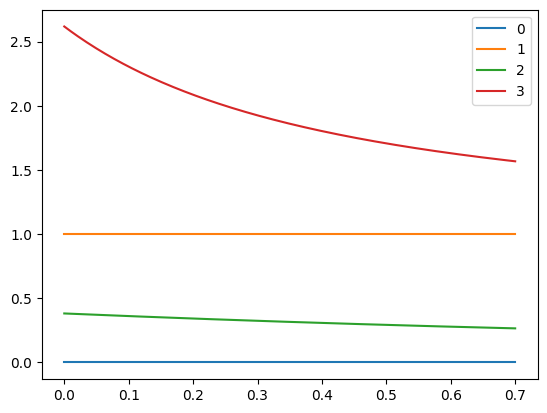

In [ ]:
for i, root in enumerate( lambdify( l, xg, 'numpy' )(ls) ):
    plt.plot( ls, 0*ls + root, label=i )
plt.legend()

In [21]:
xg[2]

(2*\lambda - sqrt(4*\lambda**2 + 4*\lambda + 5) + 3)/(4*\lambda + 2)

In [22]:
xh[2]

\lambda**2/2 - 2*\lambda - sqrt(\lambda**4 - 8*\lambda**3 + 18*\lambda**2 - 16*\lambda + 5)/2 + 3/2

In [34]:
solve( simplify( diff( G(G(x)), x ).subs(x, 0) - 1 ), l )[0]

-1/2 + sqrt(2)/2

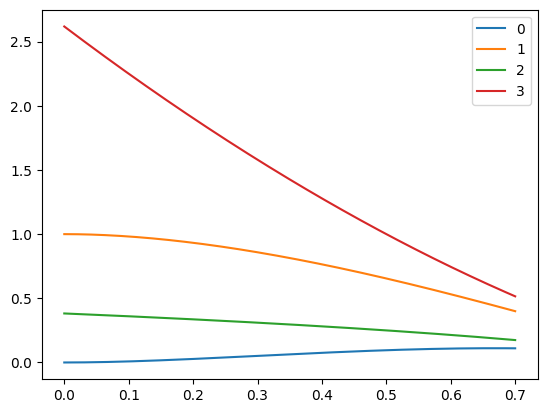

In [ ]:
for i, root in enumerate( lambdify( l, xh, 'numpy' )(ls) ):
    plt.plot( ls, root, label=i )
plt.legend()

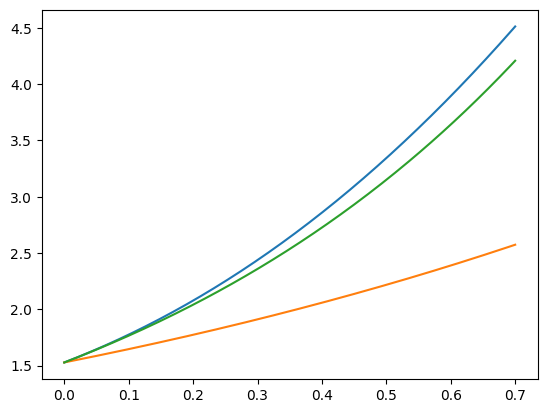

In [25]:
plt.plot( ls, lambdify( l, diff( G(x), x ).subs(x, xg[2]), 'numpy' )(ls), label=i )
plt.plot( ls, np.exp(2 * (0.21210262+0.37222673*ls)) )
plt.plot( ls, (2 * phi)**2 * np.exp( float(meta_slope_g) * ls) ) 

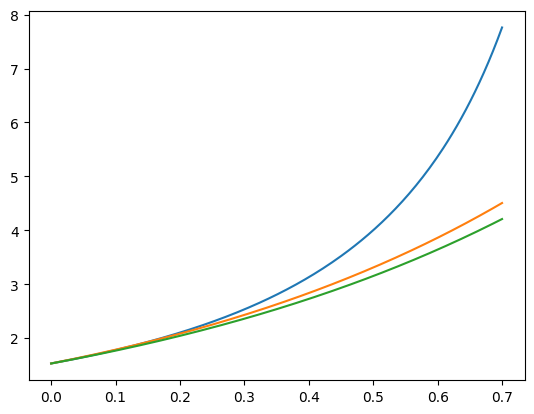

In [26]:
plt.plot( ls, lambdify( l, diff( H(x), x ).subs(x, xh[2]), 'numpy' )(ls), label=i )
plt.plot( ls, np.exp(2 * (0.21210262+0.77211985*ls)) )
plt.plot( ls, (2 * phi)**2 * np.exp( float(meta_slope_h) * ls) ) 

In [130]:
m = 3
x = symbols('x', real=True)

f = lambda x: x**m * (1+m*(1-x))

F = f(1-f(1-x))

x0 = next( filter( lambda x: 0<x<1, solve(F-x,x)) )

simplify( diff(F,x).subs(x,x0) )

144*(1 - CRootOf(3*x**4 - 8*x**3 + 6*x**2 + x - 1, 1))**5*(1 + 3*CRootOf(3*x**4 - 8*x**3 + 6*x**2 + x - 1, 1))*(-(1 - CRootOf(3*x**4 - 8*x**3 + 6*x**2 + x - 1, 1))**3*(1 + 3*CRootOf(3*x**4 - 8*x**3 + 6*x**2 + x - 1, 1)) + 1)**2*CRootOf(3*x**4 - 8*x**3 + 6*x**2 + x - 1, 1)